In [1]:
# Paso 1: Instalar y cargar dataset gapminder (si es necesario)
!pip install plotly --quiet

import pandas as pd
import plotly.express as px
import matplotlib.pyplot as plt
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import seaborn as sns

# Cargar datos gapminder
df = px.data.gapminder().query("year == 2007")  # AÃ±o mÃ¡s reciente del dataset
df = df[['country', 'continent', 'gdpPercap', 'lifeExp', 'pop']]
df.head()



[notice] A new release of pip is available: 24.3.1 -> 25.0.1
[notice] To update, run: pip install --upgrade pip


,country,continent,gdpPercap,lifeExp,pop
11,Afghanistan,Asia,974.580338,43.828,31889923
23,Albania,Europe,5937.029526,76.423,3600523
35,Algeria,Africa,6223.367465,72.301,33333216
47,Angola,Africa,4797.231267,42.731,12420476
59,Argentina,Americas,12779.379640,75.320,40301927


In [2]:
X = df[['gdpPercap', 'lifeExp', 'pop']]
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


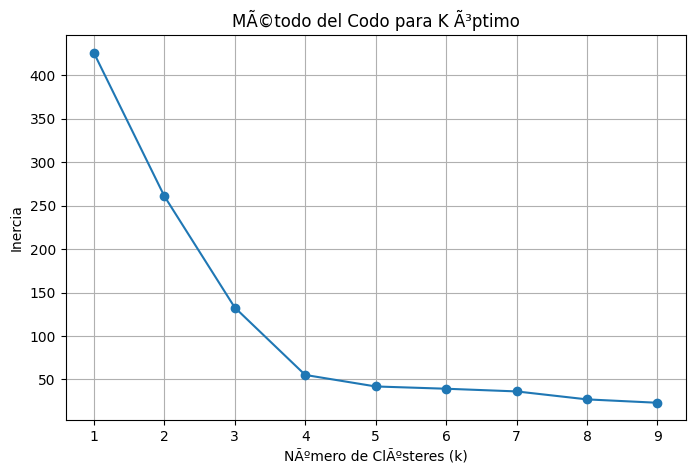

In [3]:
inertia = []
k_range = range(1, 10)

for k in k_range:
    kmeans = KMeans(n_clusters=k, random_state=42)
    kmeans.fit(X_scaled)
    inertia.append(kmeans.inertia_)

plt.figure(figsize=(8, 5))
plt.plot(k_range, inertia, marker='o')
plt.title("MÃ©todo del Codo para K Ã³ptimo")
plt.xlabel("NÃºmero de ClÃºsteres (k)")
plt.ylabel("Inercia")
plt.grid(True)
plt.show()


In [4]:
kmeans = KMeans(n_clusters=4, random_state=42)
df['cluster'] = kmeans.fit_predict(X_scaled)


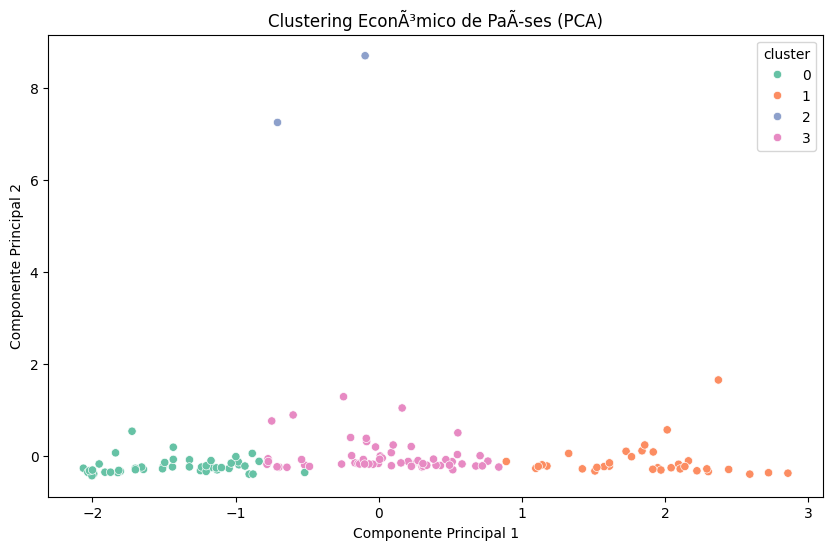

In [5]:
pca = PCA(n_components=2)
X_pca = pca.fit_transform(X_scaled)
df['pca1'] = X_pca[:, 0]
df['pca2'] = X_pca[:, 1]

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='pca1', y='pca2', hue='cluster', palette='Set2')
plt.title("Clustering EconÃ³mico de PaÃ­ses (PCA)")
plt.xlabel("Componente Principal 1")
plt.ylabel("Componente Principal 2")
plt.show()


In [6]:
fig = px.choropleth(
    df,
    locations="country",
    locationmode="country names",
    color="cluster",
    hover_name="country",
    color_continuous_scale="viridis",  # â† AquÃ­ el cambio importante
    title="Mapa Mundial: ClÃºster EconÃ³mico de PaÃ­ses (K-Means)"
)

fig.show()



In [7]:
# Ver media de cada variable por cluster
df.groupby('cluster')[['gdpPercap', 'lifeExp', 'pop']].mean()


,gdpPercap,lifeExp,pop
cluster,,,
0,2400.701897,51.438435,1.906871e+07
1,32293.373399,79.304088,3.007729e+07
2,3705.662630,68.829500,1.214540e+09
3,7379.198173,71.914800,3.203575e+07
